# Electricity Incident Prediction - Quick EDA and Results

This notebook helps inspect the generated dataset and baseline model behavior.

## Raw demand dataset

Auxiliary functions to plot data from raw and supervised datasets

In [33]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DEMAND_PATH = ROOT / "data" / "raw" / "demand_2021_2025.csv"
SUP_PATH    = ROOT / "data" / "processed" / "supervised_2021_2025.csv"

def load_demand(path: Path | str = None):
    path = Path(path) if path is not None else DEMAND_PATH
    df = pd.read_csv(path)
    date_candidates = [c for c in df.columns if any(k in c.lower() for k in ("time", "date", "ts", "datetime"))]
    date_col = date_candidates[0] if date_candidates else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", utc=True)
    df = df.set_index(date_col).sort_index()
    demand_candidates = [c for c in df.columns if any(k in c.lower() for k in ("demand", "load", "mw"))]
    if not demand_candidates:
        demand_candidates = df.select_dtypes("number").columns.tolist()
    demand_col = demand_candidates[0]
    return df, demand_col

def load_incidents(path: Path | str = None):
    path = Path(path) if path is not None else SUP_PATH
    sup = pd.read_csv(path)
    # expect a timestamp column named like 'timestamp_target_start'
    ts_col = next((c for c in sup.columns if "timestamp" in c.lower()), None)
    if ts_col is None:
        raise ValueError("Could not find a timestamp column in supervised file")
    sup[ts_col] = pd.to_datetime(sup[ts_col], errors="coerce", utc=True)
    incidents = sup[sup.get("target", 0) == 1].copy()
    incidents = incidents.rename(columns={ts_col: "ts"})
    incidents = incidents.sort_values("ts")
    return incidents

def plot_demand(df, demand_col, incidents=None, start_date=None, end_date=None,
                ax=None, figsize=(14,4), title=None, incident_marker=dict(color="red", s=30, zorder=5)):
    start = pd.to_datetime(start_date, utc=True) if start_date is not None else df.index.min()
    end   = pd.to_datetime(end_date,   utc=True) if end_date   is not None else df.index.max()
    start = max(start, df.index.min())
    end   = min(end, df.index.max())
    if start > end:
        raise ValueError("start_date must be before end_date after clipping to data range")
    subset = df.loc[start:end, demand_col]

    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_ax = True

    subset.plot(ax=ax, label="Demand")
    ax.set_xlabel("Time")
    ax.set_ylabel(demand_col)

    if incidents is not None and not incidents.empty:
        # get incident timestamps in range
        inc_ts = pd.to_datetime(incidents["ts"], utc=True)
        inc_ts = inc_ts[(inc_ts >= start) & (inc_ts <= end)]
        if not inc_ts.empty:
            # pick demand values at/near incident timestamps (nearest index)
            demand_series = df[demand_col]
            # reindex with nearest (data is hourly)
            demand_at_inc = demand_series.reindex(inc_ts, method="nearest")
            ax.scatter(demand_at_inc.index, demand_at_inc.values,
                       label="Incidents", **incident_marker)
    ax.legend()
    ax.set_title(title or f"Demand ({start.date()} — {end.date()})")
    if created_ax:
        plt.tight_layout()
        plt.show()
    return ax


In [42]:
df = pd.read_csv(DEMAND_PATH)
df.head()

,datetime,demand_mw
0,2021-01-01 00:00:00+01:00,24656.632
1,2021-01-01 01:00:00+01:00,23383.418
2,2021-01-01 02:00:00+01:00,21273.532
3,2021-01-01 03:00:00+01:00,19589.138
4,2021-01-01 04:00:00+01:00,18755.911


In [41]:
print("Rows:", len(df))

Rows: 43824


### Demand from 2021 to 2025

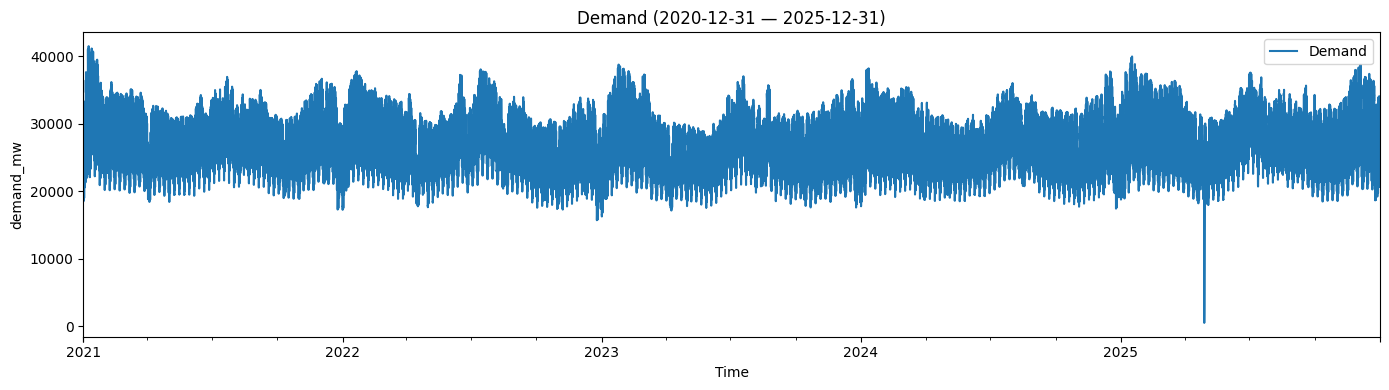

<Axes: title={'center': 'Demand (2020-12-31 — 2025-12-31)'}, xlabel='Time', ylabel='demand_mw'>

In [34]:
# load data
df_demand, demand_col = load_demand()

# whole timeline
plot_demand(df_demand, demand_col)

### Iberia power outage (2025-04-30)

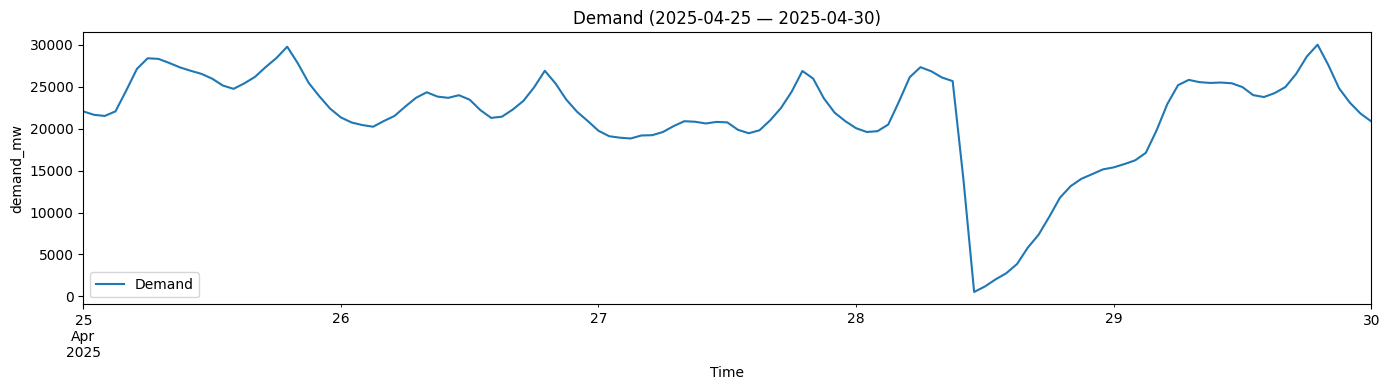

<Axes: title={'center': 'Demand (2025-04-25 — 2025-04-30)'}, xlabel='Time', ylabel='demand_mw'>

In [35]:
plot_demand(df_demand, demand_col, start_date='2025-04-25', end_date='2025-04-30')

### Anual comparison

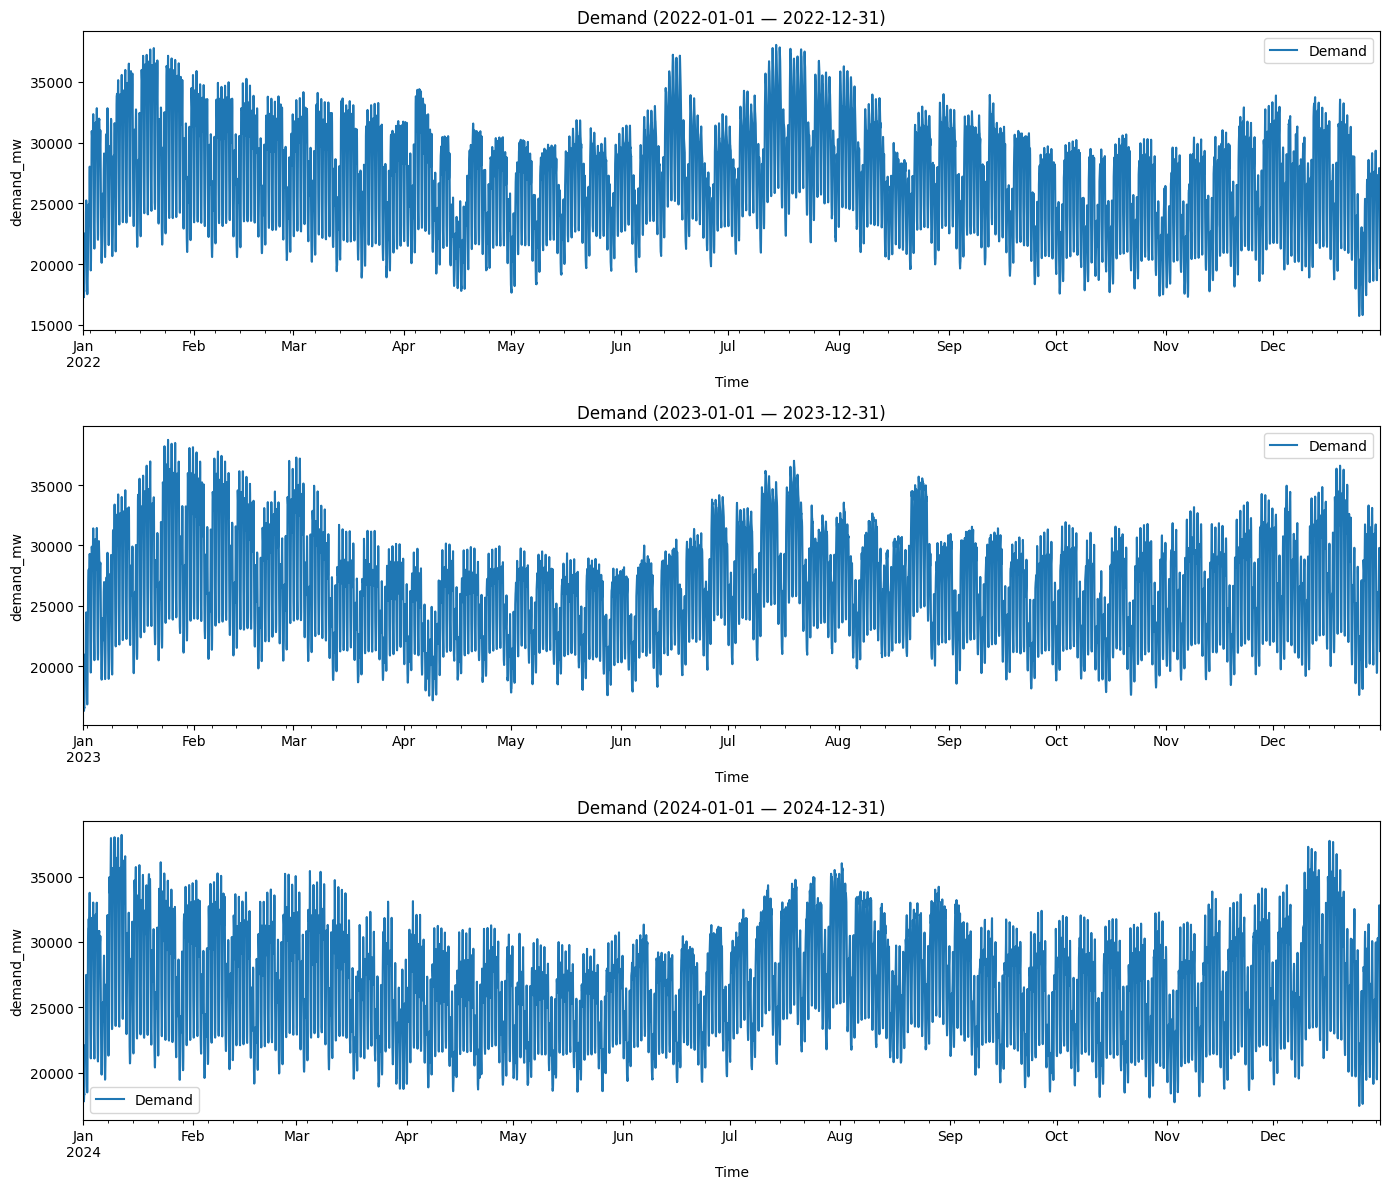

In [36]:
# multiple periods (stacked plots)
periods = [
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
    ("2024-01-01", "2024-12-31"),
]
fig, axes = plt.subplots(len(periods), 1, figsize=(14, 4 * len(periods)), squeeze=False)
for ax, (s, e) in zip(axes.ravel(), periods):
    plot_demand(df_demand, demand_col, start_date=s, end_date=e, ax=ax)
plt.tight_layout()
plt.show()

## Incidents dataset

In [ ]:
df = pd.read_csv(SUP_PATH)
df.head()

Rows: 43632
Positive rate: 0.24697469746974698


In [45]:
print("Rows:", len(df))
print("Positive rate:", df["target"].mean())

Rows: 43632
Positive rate: 0.24697469746974698


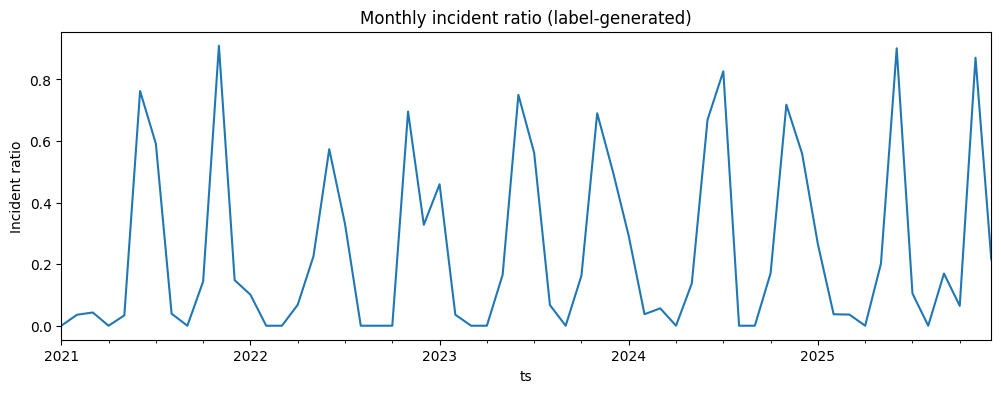

In [ ]:
target_by_month = (
    df.assign(ts=pd.to_datetime(df["timestamp_target_start"]))
    .set_index("ts")["target"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(12, 4))
target_by_month.plot()
plt.title("Monthly incident ratio (label-generated)")
plt.ylabel("Incident ratio")
plt.show()

### When do incidents happen most?

Simple counts by weekday and month for rows labeled as incidents (`target == 1`).

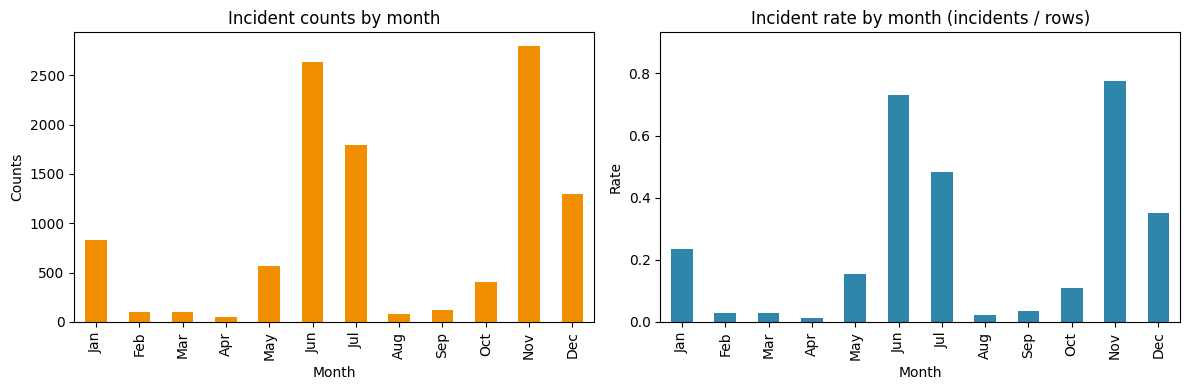

Month counts:
month
Jan     831
Feb      99
Mar     101
Apr      49
May     568
Jun    2633
Jul    1797
Aug      79
Sep     122
Oct     403
Nov    2797
Dec    1297
Name: count, dtype: int64

Month rates:
month
Jan    0.233887
Feb    0.029255
Mar    0.027151
Apr    0.013611
May    0.152688
Jun    0.731389
Jul    0.483065
Aug    0.021237
Sep    0.033889
Oct    0.108333
Nov    0.776944
Dec    0.351015
Name: count, dtype: float64

Incidents per year x month:
month  Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
year                                                             
2021     0   24   32    0   25  549  440   29    0  107  655  110
2022    75    0    0   49  168  413  246    0    0    0  501  244
2023   342   24    0    0  123  540  418   50    0  121  497  372
2024   217   26   42    0  102  482  615    0    0  127  517  416
2025   197   25   27    0  150  649   78    0  122   48  627  155

Top-3 months per year:
year
2021    [Nov, Jun, Jul]
2022    [Nov, Jun, Jul]
20

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# use existing df if present, otherwise load
try:
    df
except NameError:
    df = pd.read_csv(
        "data/processed/supervised_2021_2025.csv",
        parse_dates=["timestamp_target_start"],
    )

# ensure timestamp is datetime
if not np.issubdtype(df.timestamp_target_start.dtype, np.datetime64):
    df["timestamp_target_start"] = pd.to_datetime(df["timestamp_target_start"])

df["month"] = df.timestamp_target_start.dt.month_name().str[:3]
df["year"] = df.timestamp_target_start.dt.year

inc = df[df.target == 1]
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# counts and normalized rates
month_counts = inc.month.value_counts().reindex(month_order, fill_value=0)
month_totals = df.month.value_counts().reindex(month_order, fill_value=0)
month_rate = month_counts / month_totals.replace(0, np.nan)

# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
month_counts.plot(kind="bar", ax=axes[0], color="#F18F01")
axes[0].set_title("Incident counts by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Counts")

month_rate.plot(kind="bar", ax=axes[1], color="#2E86AB")
axes[1].set_title("Incident rate by month (incidents / rows)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Rate")
axes[1].set_ylim(
    0, (month_rate.dropna().max() * 1.2) if month_rate.dropna().size else 1
)

plt.tight_layout()
plt.show()

print("Month counts:")
print(month_counts)
print("\nMonth rates:")
print(month_rate)

# per-year consistency table
per_year = inc.groupby(["year", "month"]).size().unstack(fill_value=0)[month_order]
print("\nIncidents per year x month:")
print(per_year)

# top-3 months per year and frequency
top3_per_year = per_year.apply(
    lambda r: r.sort_values(ascending=False).head(3).index.tolist(), axis=1
)
print("\nTop-3 months per year:")
print(top3_per_year)
top3_flat = [m for lst in top3_per_year for m in lst]
top3_counts = pd.Series(top3_flat).value_counts().reindex(month_order, fill_value=0)
print("\nHow often each month appears in yearly top-3:")
print(top3_counts)

### Incidents in original dataset

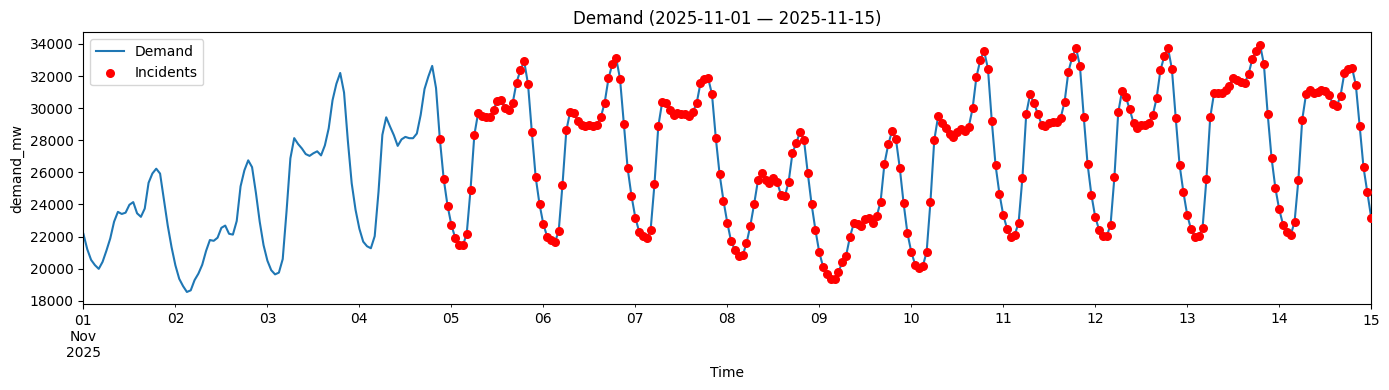

<Axes: title={'center': 'Demand (2025-11-01 — 2025-11-15)'}, xlabel='Time', ylabel='demand_mw'>

In [38]:
# --- Usage ---
df_demand, demand_col = load_demand()
incidents = load_incidents()

# specific period
plot_demand(
    df_demand,
    demand_col,
    incidents=incidents,
    start_date="2025-11-01",
    end_date="2025-11-15",
)